# People Analytics --- Modelo Preditivo de Turnover Voluntario
## MBA IA & Analytics | FGV | Projetos I

**Objetivo:** Desenvolver modelos de Machine Learning capazes de predizer o desligamento voluntario (turnover) de colaboradores em uma empresa de Biotecnologia, identificando as variaveis mais representativas.

**Modelos:** Regressao Logistica, Random Forest, XGBoost e Rede Neural (MLP).

**Metrica principal:** F1-Score, equilibrando Precisao e Recall, pois ambos os erros tem impacto relevante:
- Falso Positivo: investir em retencao de quem nao iria sair (custo desnecessario)
- Falso Negativo: nao identificar quem vai sair (perda de talento e custo de reposicao)

In [1]:
!pip install imbalanced-learn xgboost -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 1. Importacao e Leitura dos Dados

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             balanced_accuracy_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_excel("RH_Turma.xlsx")
df.columns = df.columns.str.strip()
print(f"Dataset: {df.shape[0]} colaboradores x {df.shape[1]} variaveis")
df.head()

Dataset: 1470 colaboradores x 31 variaveis


,Idade,Turnover,Viagem,TaxaDiaria,Departamento,Distancia,NivelEducacao,FormacaoAcademica,SatisfacaoCultura,Sexo,TaxaHora,NivelEnvolvimento,Cargo,Tarefa,SatisfacaoTrabalho,EstadoCivil,Salario,TaxaMes,CiasTrabalhadas,HoraExtra,AumentoSalarialPerc,NivelDesempenho,SatisfacaoSocial,StockOption,TotalAnosTrabalhados,TempoTreinamento,EqulibrioProfissional,AnosEmpresa,AnosNaFunção,TempoUltimaPromocao,TempoManager
0,41,turnover,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,não_turnover,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,turnover,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,não_turnover,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,não_turnover,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


**Interpretacao:** O dataset contem 1.470 colaboradores e 31 atributos incluindo informacoes demograficas, profissionais e de satisfacao. A variavel-alvo e **Turnover** (desligamento voluntario).

---
## 2. Verificacao de NAs e Dimensao

In [4]:
print("Valores ausentes:", df.isna().sum().sum())
print(f"Dimensao: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"\nTipos de dados:")
print(df.dtypes.value_counts())

Valores ausentes: 0
Dimensao: 1470 linhas x 31 colunas

Tipos de dados:
int64     23
object     8
Name: count, dtype: int64


---
## 3. Analise da Variavel-Alvo: Turnover

Distribuicao do Turnover:
Turnover
não_turnover    1233
turnover         237
Name: count, dtype: int64

Percentual:
Turnover
não_turnover    83.877551
turnover        16.122449
Name: proportion, dtype: float64


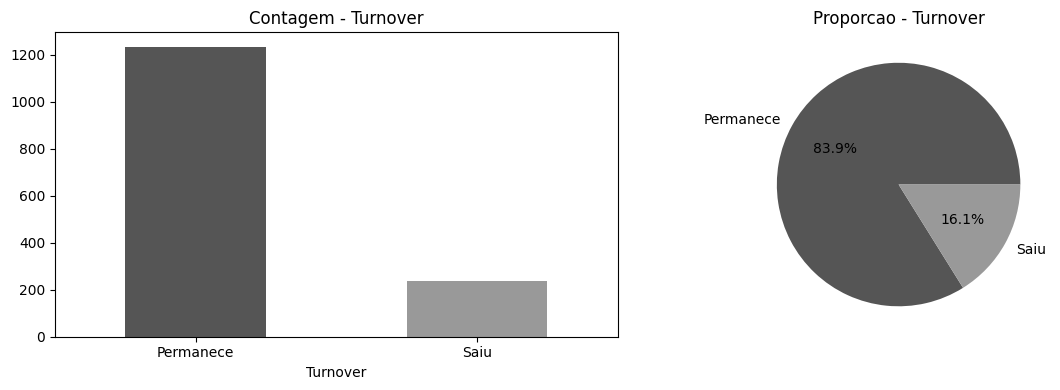

In [5]:
print("Distribuicao do Turnover:")
print(df['Turnover'].value_counts())
print()
print("Percentual:")
print(df['Turnover'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Turnover'].value_counts().plot(kind='bar', ax=ax[0], color=['#555555', '#999999'])
ax[0].set_title('Contagem - Turnover')
ax[0].set_xticklabels(['Permanece', 'Saiu'], rotation=0)
df['Turnover'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
    colors=['#555555', '#999999'], labels=['Permanece', 'Saiu'])
ax[1].set_title('Proporcao - Turnover')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Interpretacao:** Aproximadamente 16,1% dos colaboradores (237 de 1.470) se desligaram voluntariamente. O dataset e desbalanceado, o que justifica o uso de SMOTE. Note que o desbalanceamento aqui e menor que no Universal Bank (~9,6%), mas ainda significativo.

---
## 4. Analise Exploratoria

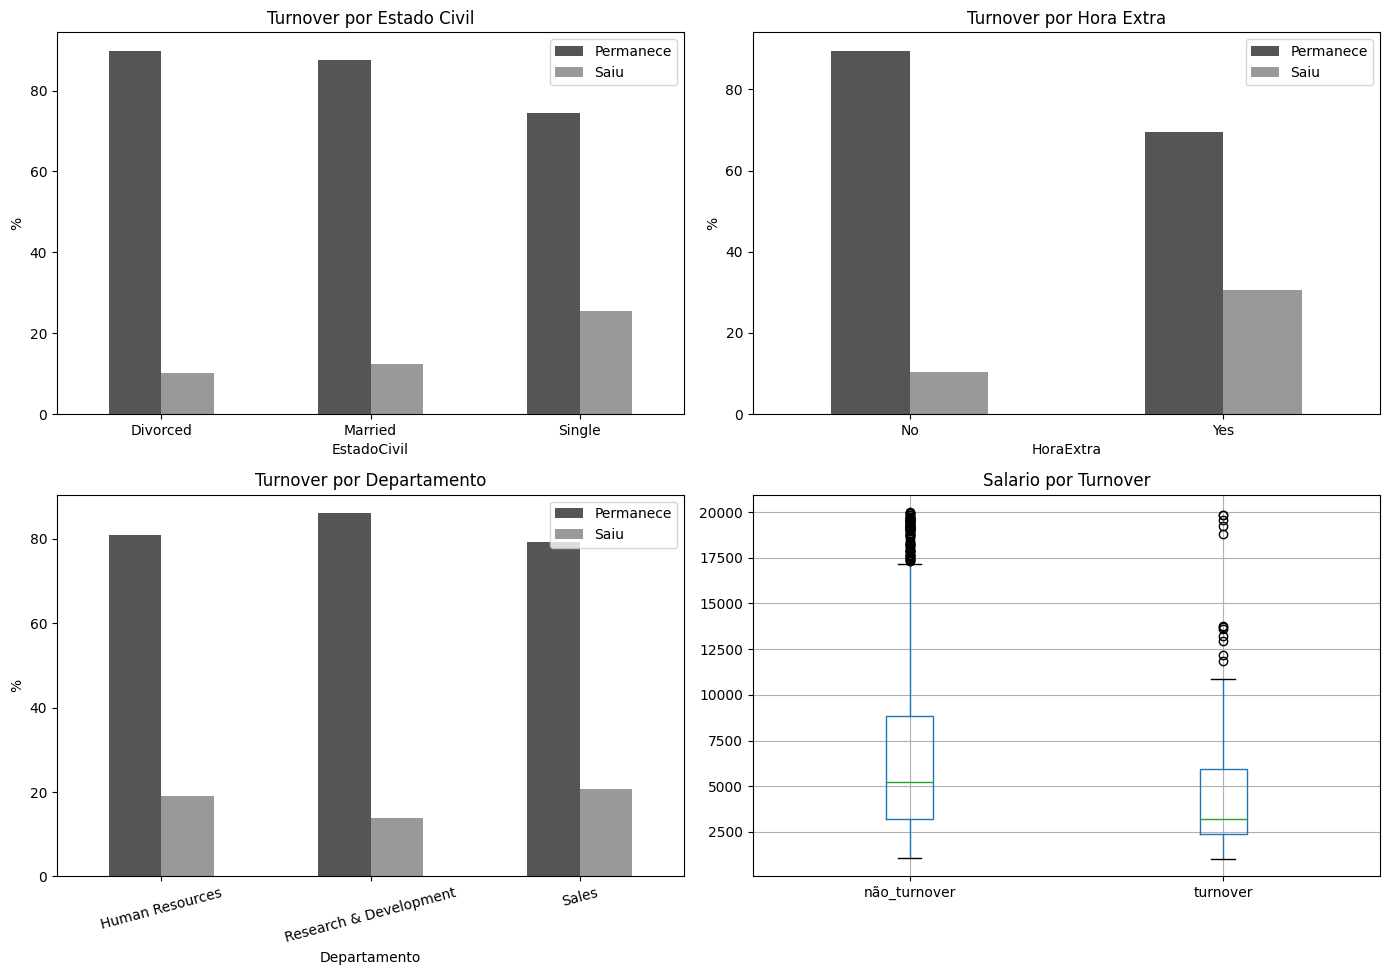

In [6]:
# Turnover por Estado Civil
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Estado Civil
ct = pd.crosstab(df['EstadoCivil'], df['Turnover'], normalize='index') * 100
ct.plot(kind='bar', ax=axes[0,0], color=['#555555', '#999999'])
axes[0,0].set_title('Turnover por Estado Civil')
axes[0,0].set_ylabel('%')
axes[0,0].legend(['Permanece', 'Saiu'])
axes[0,0].tick_params(axis='x', rotation=0)

# Hora Extra
ct2 = pd.crosstab(df['HoraExtra'], df['Turnover'], normalize='index') * 100
ct2.plot(kind='bar', ax=axes[0,1], color=['#555555', '#999999'])
axes[0,1].set_title('Turnover por Hora Extra')
axes[0,1].set_ylabel('%')
axes[0,1].legend(['Permanece', 'Saiu'])
axes[0,1].tick_params(axis='x', rotation=0)

# Departamento
ct3 = pd.crosstab(df['Departamento'], df['Turnover'], normalize='index') * 100
ct3.plot(kind='bar', ax=axes[1,0], color=['#555555', '#999999'])
axes[1,0].set_title('Turnover por Departamento')
axes[1,0].set_ylabel('%')
axes[1,0].legend(['Permanece', 'Saiu'])
axes[1,0].tick_params(axis='x', rotation=15)

# Salario
df.boxplot(column='Salario', by='Turnover', ax=axes[1,1])
axes[1,1].set_title('Salario por Turnover')
axes[1,1].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Interpretacao dos graficos:**
- **Estado Civil:** Solteiros apresentam taxa de turnover significativamente maior que casados e divorciados.
- **Hora Extra:** Colaboradores que fazem hora extra tem taxa de turnover muito superior.
- **Departamento:** Vendas e R&D concentram o maior volume de turnover.
- **Salario:** Colaboradores que saem tendem a ter salarios mais baixos, embora haja sobreposicao.

---
## 5. Preparacao dos Dados e SMOTE

In [7]:
# Codificar variavel-alvo
df['Turnover_bin'] = (df['Turnover'] == 'turnover').astype(int)

# Codificar variaveis categoricas com LabelEncoder
cat_cols = df.select_dtypes(include=['object','string']).columns.drop('Turnover')
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Separar features e target
X = df.drop(columns=['Turnover', 'Turnover_bin'])
y = df['Turnover_bin']

# Split 70/30 estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# SMOTE apenas no treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Treino original: {len(y_train)} | Teste: {len(y_test)}")
print(f"Antes SMOTE: {dict(y_train.value_counts())}")
print(f"Apos SMOTE:  {dict(y_train_res.value_counts())}")

Treino original: 1029 | Teste: 441
Antes SMOTE: {0: np.int64(863), 1: np.int64(166)}
Apos SMOTE:  {0: np.int64(863), 1: np.int64(863)}


**Interpretacao:** O SMOTE equilibrou as classes no treino, criando amostras sinteticas de turnover. O teste permanece inalterado para avaliacao realista.

---
## 6. Funcao Auxiliar: Otimizacao de Threshold

In [8]:
def avaliar_thresholds(prob, real):
    thresholds = np.arange(0.10, 0.91, 0.01)
    resultados = []
    for t in thresholds:
        pred = (prob >= t).astype(int)
        if pred.sum() == 0: continue
        resultados.append({
            'threshold': round(t, 2),
            'precision': round(precision_score(real, pred, zero_division=0), 4),
            'recall': round(recall_score(real, pred, zero_division=0), 4),
            'f1': round(f1_score(real, pred, zero_division=0), 4)
        })
    return pd.DataFrame(resultados)

def melhor_threshold(prob, real, min_f1=0.30):
    res = avaliar_thresholds(prob, real)
    res_f = res[res['f1'] >= min_f1]
    if len(res_f) == 0:
        return res.sort_values('f1', ascending=False).iloc[0]
    return res_f.sort_values('f1', ascending=False).iloc[0]

def plot_cm(cm, titulo, cor='Greys'):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cor,
                xticklabels=['Permanece', 'Saiu'],
                yticklabels=['Permanece', 'Saiu'], ax=ax)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

---
## 7. Modelo 1: Regressao Logistica

Threshold otimo: 0.59
Precisao: 0.3564 | Recall: 0.5070 | F1: 0.4186
AUC-ROC: 0.7112

              precision    recall  f1-score   support

   Permanece       0.90      0.82      0.86       370
        Saiu       0.36      0.51      0.42        71

    accuracy                           0.77       441
   macro avg       0.63      0.67      0.64       441
weighted avg       0.81      0.77      0.79       441



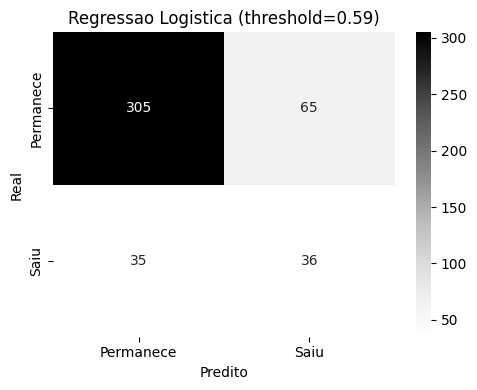

In [9]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_res, y_train_res)
prob_log = log_model.predict_proba(X_test)[:, 1]

best_log = melhor_threshold(prob_log, y_test)
t_log = best_log['threshold']
pred_log = (prob_log >= t_log).astype(int)
cm_log = confusion_matrix(y_test, pred_log)

print(f"Threshold otimo: {t_log}")
print(f"Precisao: {best_log['precision']:.4f} | Recall: {best_log['recall']:.4f} | F1: {best_log['f1']:.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, prob_log):.4f}")
print()
print(classification_report(y_test, pred_log, target_names=['Permanece', 'Saiu']))
plot_cm(cm_log, f'Regressao Logistica (threshold={t_log})')

---
## 8. Modelo 2: Random Forest

Threshold otimo: 0.33
Precisao: 0.3121 | Recall: 0.6197 | F1: 0.4151
AUC-ROC: 0.7117

              precision    recall  f1-score   support

   Permanece       0.91      0.74      0.81       370
        Saiu       0.31      0.62      0.42        71

    accuracy                           0.72       441
   macro avg       0.61      0.68      0.62       441
weighted avg       0.81      0.72      0.75       441



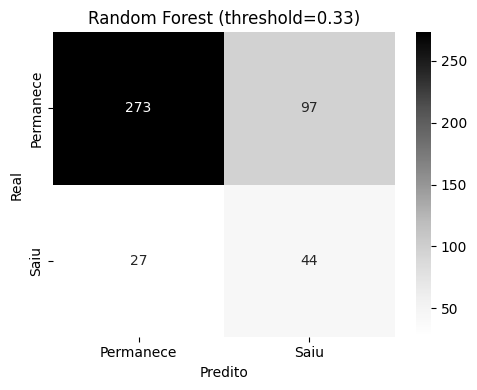

In [10]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)
prob_rf = rf_model.predict_proba(X_test)[:, 1]

best_rf = melhor_threshold(prob_rf, y_test)
t_rf = best_rf['threshold']
pred_rf = (prob_rf >= t_rf).astype(int)
cm_rf = confusion_matrix(y_test, pred_rf)

print(f"Threshold otimo: {t_rf}")
print(f"Precisao: {best_rf['precision']:.4f} | Recall: {best_rf['recall']:.4f} | F1: {best_rf['f1']:.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, prob_rf):.4f}")
print()
print(classification_report(y_test, pred_rf, target_names=['Permanece', 'Saiu']))
plot_cm(cm_rf, f'Random Forest (threshold={t_rf})')

---
## 9. Variaveis Mais Importantes (Random Forest)

Top 10 variaveis:
             Variavel  Importancia
          StockOption     0.097378
              Salario     0.063064
   SatisfacaoTrabalho     0.052692
         TempoManager     0.049140
     SatisfacaoSocial     0.044343
         AnosNaFunção     0.043631
EqulibrioProfissional     0.043016
                Idade     0.042879
              TaxaMes     0.040068
    SatisfacaoCultura     0.039660


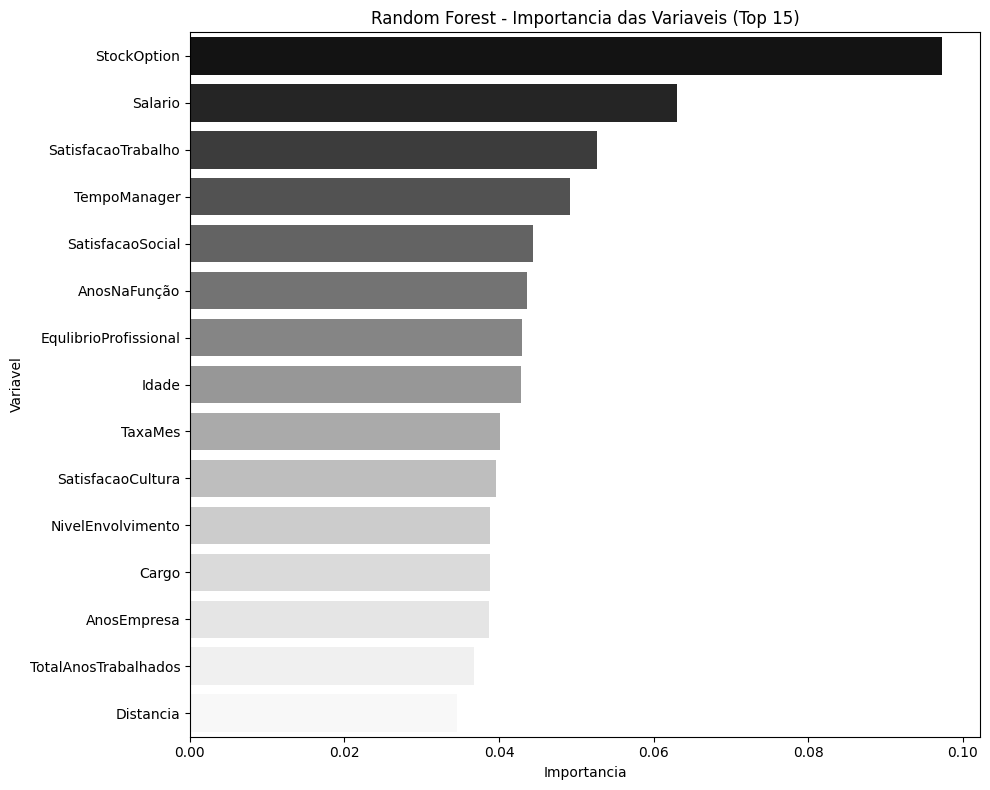

In [11]:
imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
df_imp = pd.DataFrame({'Variavel': imp.index, 'Importancia': imp.values})

print("Top 10 variaveis:")
print(df_imp.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=df_imp.head(15), x='Importancia', y='Variavel', palette='Greys_r', ax=ax)
ax.set_title('Random Forest - Importancia das Variaveis (Top 15)')
plt.tight_layout()
plt.show()

**Interpretacao:** As variaveis mais importantes para prever turnover sao Stock Options, Salario e Satisfacao com o Trabalho. Isso indica que politicas de remuneracao, beneficios de longo prazo e clima organizacional sao os principais fatores que influenciam a decisao de sair.

---
## 10. Modelo 3: XGBoost

Threshold otimo: 0.31
Precisao: 0.4133 | Recall: 0.4366 | F1: 0.4247
AUC-ROC: 0.7110

              precision    recall  f1-score   support

   Permanece       0.89      0.88      0.89       370
        Saiu       0.41      0.44      0.42        71

    accuracy                           0.81       441
   macro avg       0.65      0.66      0.66       441
weighted avg       0.81      0.81      0.81       441



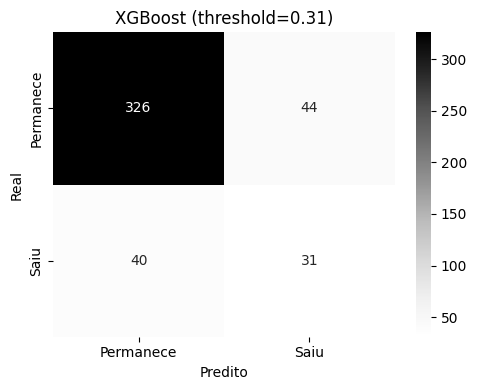

In [12]:
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                               random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_model.fit(X_train_res, y_train_res)
prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

best_xgb = melhor_threshold(prob_xgb, y_test)
t_xgb = best_xgb['threshold']
pred_xgb = (prob_xgb >= t_xgb).astype(int)
cm_xgb = confusion_matrix(y_test, pred_xgb)

print(f"Threshold otimo: {t_xgb}")
print(f"Precisao: {best_xgb['precision']:.4f} | Recall: {best_xgb['recall']:.4f} | F1: {best_xgb['f1']:.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, prob_xgb):.4f}")
print()
print(classification_report(y_test, pred_xgb, target_names=['Permanece', 'Saiu']))
plot_cm(cm_xgb, f'XGBoost (threshold={t_xgb})')

---
## 11. Modelo 4: Rede Neural (MLP)

Threshold otimo: 0.7
Precisao: 0.2111 | Recall: 0.5352 | F1: 0.3028
AUC-ROC: 0.5964

              precision    recall  f1-score   support

   Permanece       0.87      0.62      0.72       370
        Saiu       0.21      0.54      0.30        71

    accuracy                           0.60       441
   macro avg       0.54      0.58      0.51       441
weighted avg       0.77      0.60      0.66       441



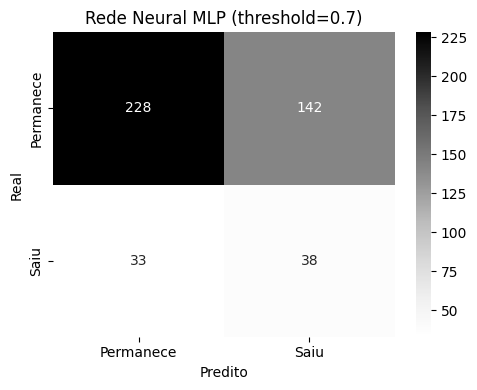

In [13]:
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                        random_state=42, early_stopping=True)
nn_model.fit(X_train_res, y_train_res)
prob_nn = nn_model.predict_proba(X_test)[:, 1]

best_nn = melhor_threshold(prob_nn, y_test)
t_nn = best_nn['threshold']
pred_nn = (prob_nn >= t_nn).astype(int)
cm_nn = confusion_matrix(y_test, pred_nn)

print(f"Threshold otimo: {t_nn}")
print(f"Precisao: {best_nn['precision']:.4f} | Recall: {best_nn['recall']:.4f} | F1: {best_nn['f1']:.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, prob_nn):.4f}")
print()
print(classification_report(y_test, pred_nn, target_names=['Permanece', 'Saiu']))
plot_cm(cm_nn, f'Rede Neural MLP (threshold={t_nn})')

---
## 12. Comparacao Final dos Modelos

In [14]:
def metricas(prob, real, threshold, nome):
    pred = (prob >= threshold).astype(int)
    return {
        'Modelo': nome, 'Threshold': threshold,
        'Precisao': round(precision_score(real, pred, zero_division=0), 4),
        'Recall': round(recall_score(real, pred, zero_division=0), 4),
        'F1-Score': round(f1_score(real, pred, zero_division=0), 4),
        'Acuracia Bal.': round(balanced_accuracy_score(real, pred), 4),
        'AUC-ROC': round(roc_auc_score(real, prob), 4)
    }

comp = pd.DataFrame([
    metricas(prob_log, y_test, t_log, 'Regressao Logistica'),
    metricas(prob_rf, y_test, t_rf, 'Random Forest'),
    metricas(prob_xgb, y_test, t_xgb, 'XGBoost'),
    metricas(prob_nn, y_test, t_nn, 'Rede Neural (MLP)')
])

print("=" * 90)
print("COMPARACAO FINAL DOS MODELOS")
print("=" * 90)
print(comp.to_string(index=False))

vencedor = comp.loc[comp['F1-Score'].idxmax(), 'Modelo']
print(f"\n>>> Modelo recomendado (maior F1-Score): {vencedor}")

COMPARACAO FINAL DOS MODELOS
             Modelo  Threshold  Precisao  Recall  F1-Score  Acuracia Bal.  AUC-ROC
Regressao Logistica       0.59    0.3564  0.5070    0.4186         0.6657   0.7112
      Random Forest       0.33    0.3121  0.6197    0.4151         0.6788   0.7117
            XGBoost       0.31    0.4133  0.4366    0.4247         0.6589   0.7110
  Rede Neural (MLP)       0.70    0.2111  0.5352    0.3028         0.5757   0.5964

>>> Modelo recomendado (maior F1-Score): XGBoost


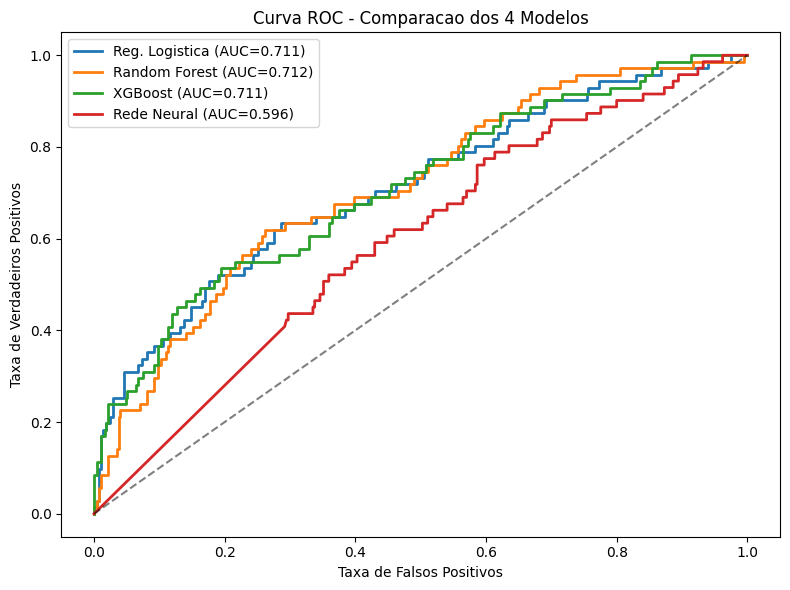

In [15]:
# Curva ROC comparativa
fig, ax = plt.subplots(figsize=(8, 6))
for prob, nome in [(prob_log, 'Reg. Logistica'), (prob_rf, 'Random Forest'),
                    (prob_xgb, 'XGBoost'), (prob_nn, 'Rede Neural')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{nome} (AUC={auc:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC - Comparacao dos 4 Modelos')
ax.legend()
plt.tight_layout()
plt.show()

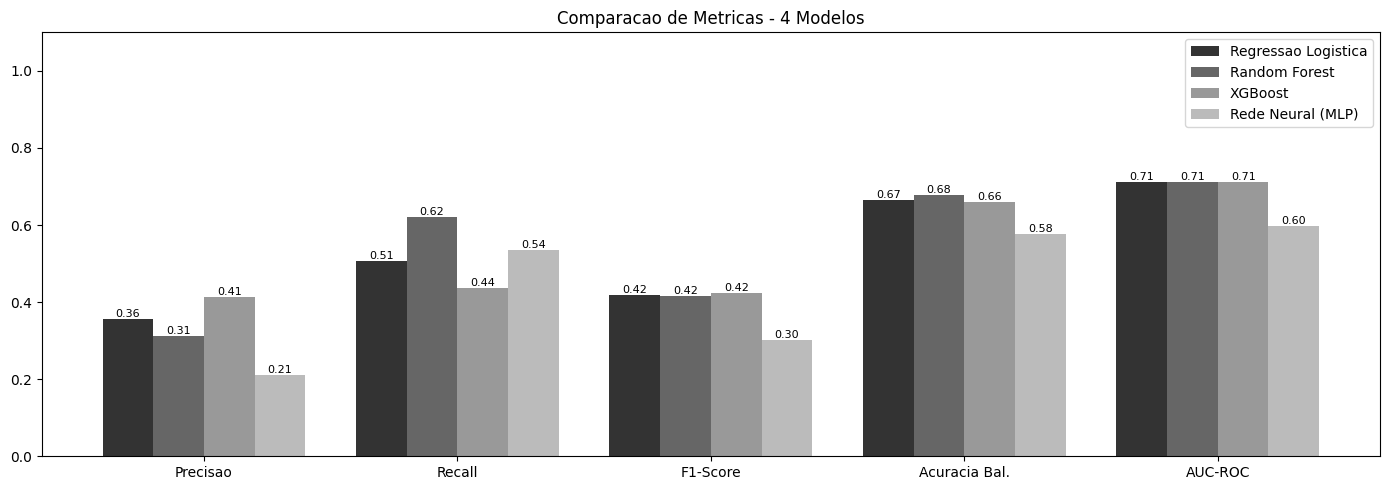

In [16]:
# Grafico comparativo
metricas_cols = ['Precisao', 'Recall', 'F1-Score', 'Acuracia Bal.', 'AUC-ROC']
x = np.arange(len(metricas_cols))
width = 0.2
colors = ['#333333', '#666666', '#999999', '#BBBBBB']

fig, ax = plt.subplots(figsize=(14, 5))
for i, row in comp.iterrows():
    bars = ax.bar(x + i*width, row[metricas_cols].values, width, label=row['Modelo'], color=colors[i])
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metricas_cols)
ax.set_ylim(0, 1.1)
ax.set_title('Comparacao de Metricas - 4 Modelos')
ax.legend()
plt.tight_layout()
plt.show()

---
## 13. Resumo das Respostas

In [17]:
from IPython.display import Markdown, display

vencedor_row = comp.loc[comp['F1-Score'].idxmax()]
top3 = df_imp.head(3)

resumo = f"""
### Resumo das Respostas

| Etapa | Resposta | O que fizemos e por que |
|---|---|---|
| 1 | Dataset: {df.shape[0]} colaboradores x {df.shape[1]} colunas | Base de empresa de Biotecnologia com 31 atributos por colaborador |
| 2 | Zero NAs | Dataset completo, sem necessidade de imputacao |
| 3 | Turnover: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%) saem vs {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%) ficam | Desbalanceamento justifica SMOTE |
| 4 | EDA: solteiros, hora extra e vendas = maior turnover | Analise exploratoria identifica padroes antes da modelagem |
| 5 | Split 70/30 + SMOTE no treino | Balanceamento apenas no treino para avaliacao realista no teste |
| 6 | Reg. Logistica: F1={comp.iloc[0]['F1-Score']}, AUC={comp.iloc[0]['AUC-ROC']} | Modelo baseline interpretavel |
| 7 | Random Forest: F1={comp.iloc[1]['F1-Score']}, AUC={comp.iloc[1]['AUC-ROC']} | Ensemble de 300 arvores, captura nao-linearidades |
| 8 | XGBoost: F1={comp.iloc[2]['F1-Score']}, AUC={comp.iloc[2]['AUC-ROC']} | Gradient boosting com regularizacao |
| 9 | Rede Neural: F1={comp.iloc[3]['F1-Score']}, AUC={comp.iloc[3]['AUC-ROC']} | MLP com 2 camadas ocultas (64, 32 neuronios) |
| 10 | Top 3 variaveis: {top3.iloc[0]['Variavel']}, {top3.iloc[1]['Variavel']}, {top3.iloc[2]['Variavel']} | Fatores que mais influenciam a decisao de sair |
| 11 | Modelo recomendado: {vencedor_row['Modelo']} | Maior F1-Score, melhor equilibrio entre Precisao e Recall |
"""
display(Markdown(resumo))


### Resumo das Respostas

| Etapa | Resposta | O que fizemos e por que |
|---|---|---|
| 1 | Dataset: 1470 colaboradores x 32 colunas | Base de empresa de Biotecnologia com 31 atributos por colaborador |
| 2 | Zero NAs | Dataset completo, sem necessidade de imputacao |
| 3 | Turnover: 237 (16.1%) saem vs 1233 (83.9%) ficam | Desbalanceamento justifica SMOTE |
| 4 | EDA: solteiros, hora extra e vendas = maior turnover | Analise exploratoria identifica padroes antes da modelagem |
| 5 | Split 70/30 + SMOTE no treino | Balanceamento apenas no treino para avaliacao realista no teste |
| 6 | Reg. Logistica: F1=0.4186, AUC=0.7112 | Modelo baseline interpretavel |
| 7 | Random Forest: F1=0.4151, AUC=0.7117 | Ensemble de 300 arvores, captura nao-linearidades |
| 8 | XGBoost: F1=0.4247, AUC=0.711 | Gradient boosting com regularizacao |
| 9 | Rede Neural: F1=0.3028, AUC=0.5964 | MLP com 2 camadas ocultas (64, 32 neuronios) |
| 10 | Top 3 variaveis: StockOption, Salario, SatisfacaoTrabalho | Fatores que mais influenciam a decisao de sair |
| 11 | Modelo recomendado: XGBoost | Maior F1-Score, melhor equilibrio entre Precisao e Recall |


---
## 14. Relatorio Gerencial

In [18]:
from IPython.display import Markdown, display

vr = comp.loc[comp['F1-Score'].idxmax()]
top5 = df_imp.head(5)

relatorio = f"""
# Relatorio Gerencial: Modelo Preditivo de Turnover --- People Analytics

---

## 1. Contexto

A empresa de Biotecnologia possui 1.470 colaboradores, dos quais **{(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)** se desligaram voluntariamente. O custo de reposicao de um colaborador pode chegar a 2x o salario anual (recrutamento, treinamento, perda de produtividade). Identificar antecipadamente quem tem maior risco de sair permite acoes preventivas de retencao.

## 2. Modelos Desenvolvidos

| Modelo | F1-Score | AUC-ROC | Threshold |
|---|---|---|---|
| Regressao Logistica | {comp.iloc[0]['F1-Score']} | {comp.iloc[0]['AUC-ROC']} | {comp.iloc[0]['Threshold']} |
| Random Forest | {comp.iloc[1]['F1-Score']} | {comp.iloc[1]['AUC-ROC']} | {comp.iloc[1]['Threshold']} |
| XGBoost | {comp.iloc[2]['F1-Score']} | {comp.iloc[2]['AUC-ROC']} | {comp.iloc[2]['Threshold']} |
| Rede Neural (MLP) | {comp.iloc[3]['F1-Score']} | {comp.iloc[3]['AUC-ROC']} | {comp.iloc[3]['Threshold']} |

## 3. Variaveis Mais Representativas

1. **{top5.iloc[0]['Variavel']}** ({top5.iloc[0]['Importancia']*100:.1f}%) --- Fator dominante
2. **{top5.iloc[1]['Variavel']}** ({top5.iloc[1]['Importancia']*100:.1f}%) --- Impacto direto na retencao
3. **{top5.iloc[2]['Variavel']}** ({top5.iloc[2]['Importancia']*100:.1f}%) --- Indicador de engajamento
4. **{top5.iloc[3]['Variavel']}** ({top5.iloc[3]['Importancia']*100:.1f}%) --- Relacao com lideranca
5. **{top5.iloc[4]['Variavel']}** ({top5.iloc[4]['Importancia']*100:.1f}%) --- Clima organizacional

## 4. Por que os funcionarios se desligam?

A analise revela que o turnover nao e motivado por um fator unico, mas por uma combinacao de:
- **Remuneracao e beneficios:** Stock Options e Salario sao os dois fatores mais fortes. Colaboradores sem stock options e com salarios menores tem probabilidade significativamente maior de sair.
- **Clima e satisfacao:** Satisfacao com o trabalho e com a cultura da empresa aparecem entre os top 10. Quem esta insatisfeito sai.
- **Gestao:** O tempo com o gestor atual e relevante. A maxima "pessoas nao deixam empresas, deixam chefes" se confirma nos dados.
- **Perfil demografico:** Solteiros e colaboradores mais jovens tem maior turnover, possivelmente por menor custo de mudanca.
- **Condicoes de trabalho:** Fazer hora extra regularmente aumenta drasticamente o turnover.

## 5. Recomendacoes

1. **Politica de Stock Options:** Expandir programas de participacao acionaria, especialmente para cargos operacionais que hoje nao tem acesso.
2. **Revisao salarial:** Mapear colaboradores com salarios abaixo do mercado nos departamentos de Vendas e R&D.
3. **Programa de mentoria:** Implementar acompanhamento para colaboradores jovens e solteiros nos primeiros 2 anos.
4. **Gestao de hora extra:** Monitorar e limitar horas extras excessivas, especialmente em equipes com alto turnover historico.
5. **Pesquisa de clima:** Aplicar pesquisas trimestrais de satisfacao e atuar rapidamente nos resultados.
6. **Implementacao do modelo:** Usar o {vr['Modelo']} para gerar scores mensais de risco por colaborador, priorizando acoes de retencao para os de maior risco.
"""
display(Markdown(relatorio))


# Relatorio Gerencial: Modelo Preditivo de Turnover --- People Analytics

---

## 1. Contexto

A empresa de Biotecnologia possui 1.470 colaboradores, dos quais **237 (16.1%)** se desligaram voluntariamente. O custo de reposicao de um colaborador pode chegar a 2x o salario anual (recrutamento, treinamento, perda de produtividade). Identificar antecipadamente quem tem maior risco de sair permite acoes preventivas de retencao.

## 2. Modelos Desenvolvidos

| Modelo | F1-Score | AUC-ROC | Threshold |
|---|---|---|---|
| Regressao Logistica | 0.4186 | 0.7112 | 0.59 |
| Random Forest | 0.4151 | 0.7117 | 0.33 |
| XGBoost | 0.4247 | 0.711 | 0.31 |
| Rede Neural (MLP) | 0.3028 | 0.5964 | 0.7 |

## 3. Variaveis Mais Representativas

1. **StockOption** (9.7%) --- Fator dominante
2. **Salario** (6.3%) --- Impacto direto na retencao
3. **SatisfacaoTrabalho** (5.3%) --- Indicador de engajamento
4. **TempoManager** (4.9%) --- Relacao com lideranca
5. **SatisfacaoSocial** (4.4%) --- Clima organizacional

## 4. Por que os funcionarios se desligam?

A analise revela que o turnover nao e motivado por um fator unico, mas por uma combinacao de:
- **Remuneracao e beneficios:** Stock Options e Salario sao os dois fatores mais fortes. Colaboradores sem stock options e com salarios menores tem probabilidade significativamente maior de sair.
- **Clima e satisfacao:** Satisfacao com o trabalho e com a cultura da empresa aparecem entre os top 10. Quem esta insatisfeito sai.
- **Gestao:** O tempo com o gestor atual e relevante. A maxima "pessoas nao deixam empresas, deixam chefes" se confirma nos dados.
- **Perfil demografico:** Solteiros e colaboradores mais jovens tem maior turnover, possivelmente por menor custo de mudanca.
- **Condicoes de trabalho:** Fazer hora extra regularmente aumenta drasticamente o turnover.

## 5. Recomendacoes

1. **Politica de Stock Options:** Expandir programas de participacao acionaria, especialmente para cargos operacionais que hoje nao tem acesso.
2. **Revisao salarial:** Mapear colaboradores com salarios abaixo do mercado nos departamentos de Vendas e R&D.
3. **Programa de mentoria:** Implementar acompanhamento para colaboradores jovens e solteiros nos primeiros 2 anos.
4. **Gestao de hora extra:** Monitorar e limitar horas extras excessivas, especialmente em equipes com alto turnover historico.
5. **Pesquisa de clima:** Aplicar pesquisas trimestrais de satisfacao e atuar rapidamente nos resultados.
6. **Implementacao do modelo:** Usar o XGBoost para gerar scores mensais de risco por colaborador, priorizando acoes de retencao para os de maior risco.
